In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/superstore_cleaned.csv')
elasticity_df = pd.read_csv('../outputs/elasticity_by_subcategory.csv')

print("Main data shape:", df.shape)
print("Elasticity data shape:", elasticity_df.shape)
df.head()

Main data shape: (9977, 22)
Elasticity data shape: (17, 8)


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,...,Profit,Unit_Price,Profit_Margin,Revenue,Discount_Band,Price_Segment,Market_Benchmark_Price_x,Market_Benchmark_Price_y,Market_Benchmark_Price,Price_vs_Market
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,...,41.9136,130.9800,16.00,261.9600,No Discount,Premium,102.833,102.833,102.833,Overpriced
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,...,219.5820,243.9800,30.00,731.9400,No Discount,Premium,105.623,105.623,105.623,Overpriced
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,...,6.8714,7.3100,47.00,14.6200,No Discount,Premium,3.984,3.984,3.984,Overpriced
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,...,-383.0310,191.5155,-40.00,957.5775,High (41%+),Premium,145.490,145.490,145.490,Overpriced
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,...,2.5164,11.1840,11.25,22.3680,Low (1-20%),Low,37.208,37.208,37.208,Underpriced


In [2]:
base = df.groupby(['Sub-Category', 'Category']).agg(
    Avg_Unit_Price=('Unit_Price', 'mean'),
    Total_Quantity=('Quantity', 'sum'),
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Profit_Margin=('Profit_Margin', 'mean'),
    Transaction_Count=('Sales', 'count')
).round(2).reset_index()

print("=== Base Metrics per Sub-Category ===")
print(base.to_string(index=False))

=== Base Metrics per Sub-Category ===
Sub-Category        Category  Avg_Unit_Price  Total_Quantity  Total_Revenue  Total_Profit  Avg_Profit_Margin  Transaction_Count
 Accessories      Technology           55.36            2976      167380.32      41936.64              21.82                775
  Appliances Office Supplies           60.62            1729      107532.16      18138.01             -15.69                466
         Art Office Supplies            8.83            2996       27107.03       6524.61              25.16                795
     Binders Office Supplies           36.70            5971      203409.17      30228.00             -19.86               1522
   Bookcases       Furniture          131.10             868      114880.00      -3472.56             -12.66                228
      Chairs       Furniture          138.81            2351      327777.76      26567.13               4.40                615
     Copiers      Technology          601.02             234      

In [3]:
elast_cols = elasticity_df[['Sub-Category', 'Proxy_Elasticity', 'Demand_Response']]
base = base.merge(elast_cols, on='Sub-Category', how='left')

print("Merged shape:", base.shape)
print(base[['Sub-Category', 'Proxy_Elasticity', 'Demand_Response']].to_string(index=False))

Merged shape: (17, 10)
Sub-Category  Proxy_Elasticity          Demand_Response
 Accessories             0.107    Unusual — Investigate
  Appliances             0.092    Unusual — Investigate
         Art             0.292    Unusual — Investigate
     Binders            -0.036 Inelastic — Price Stable
   Bookcases             1.188    Unusual — Investigate
      Chairs             0.602    Unusual — Investigate
     Copiers             0.268    Unusual — Investigate
   Envelopes             0.087    Unusual — Investigate
   Fasteners            -0.939 Inelastic — Price Stable
 Furnishings             1.012    Unusual — Investigate
      Labels             0.261    Unusual — Investigate
    Machines             0.912    Unusual — Investigate
       Paper            -0.037 Inelastic — Price Stable
      Phones            -0.404 Inelastic — Price Stable
     Storage             0.430    Unusual — Investigate
    Supplies             0.104    Unusual — Investigate
      Tables             

In [4]:
scenarios = {
    'Price -20%':  -0.20,
    'Price -10%':  -0.10,
    'Price -5%' :  -0.05,
    'Current'   :   0.00,
    'Price +5%' :   0.05,
    'Price +10%':   0.10
}

print("Scenarios defined:")
for name, val in scenarios.items():
    print(f"  {name:15} → {val*100:+.0f}% price change")

Scenarios defined:
  Price -20%      → -20% price change
  Price -10%      → -10% price change
  Price -5%       → -5% price change
  Current         → +0% price change
  Price +5%       → +5% price change
  Price +10%      → +10% price change


In [5]:
simulation_results = []

for _, row in base.iterrows():
    sub_cat        = row['Sub-Category']
    category       = row['Category']
    base_price     = row['Avg_Unit_Price']
    base_qty       = row['Total_Quantity']
    base_rev       = row['Total_Revenue']
    base_profit    = row['Total_Profit']
    elasticity     = row['Proxy_Elasticity']
    demand_response = row['Demand_Response']

    if pd.isna(elasticity):
        elasticity = 0.0

    base_margin_pct = base_profit / base_rev if base_rev != 0 else 0

    for scenario_name, price_change_pct in scenarios.items():
        new_price        = base_price * (1 + price_change_pct)
        demand_change_pct = elasticity * price_change_pct
        new_quantity     = max(base_qty * (1 + demand_change_pct), 0)
        new_revenue      = new_price * new_quantity
        new_profit       = new_revenue * base_margin_pct
        revenue_change   = new_revenue - base_rev
        profit_change    = new_profit - base_profit

        simulation_results.append({
            'Sub-Category'   : sub_cat,
            'Category'       : category,
            'Scenario'       : scenario_name,
            'Base_Price'     : round(base_price, 2),
            'New_Price'      : round(new_price, 2),
            'Base_Revenue'   : round(base_rev, 2),
            'New_Revenue'    : round(new_revenue, 2),
            'Revenue_Change' : round(revenue_change, 2),
            'Base_Profit'    : round(base_profit, 2),
            'New_Profit'     : round(new_profit, 2),
            'Profit_Change'  : round(profit_change, 2),
            'Demand_Response': demand_response
        })

sim_df = pd.DataFrame(simulation_results)
print("Simulation complete")
print("Shape:", sim_df.shape)
sim_df.head(10)

Simulation complete
Shape: (102, 12)


,Sub-Category,Category,Scenario,Base_Price,New_Price,Base_Revenue,New_Revenue,Revenue_Change,Base_Profit,New_Profit,Profit_Change,Demand_Response
0,Accessories,Technology,Price -20%,55.36,44.29,167380.32,128980.54,-38399.78,41936.64,32315.69,-9620.95,Unusual — Investigate
1,Accessories,Technology,Price -10%,55.36,49.82,167380.32,146689.67,-20690.65,41936.64,36752.66,-5183.98,Unusual — Investigate
2,Accessories,Technology,Price -5%,55.36,52.59,167380.32,155676.44,-11703.88,41936.64,39004.27,-2932.37,Unusual — Investigate
3,Accessories,Technology,Current,55.36,55.36,167380.32,164751.36,-2628.96,41936.64,41277.96,-658.68,Unusual — Investigate
4,Accessories,Technology,Price +5%,55.36,58.13,167380.32,173914.42,6534.10,41936.64,43573.74,1637.10,Unusual — Investigate
5,Accessories,Technology,Price +10%,55.36,60.90,167380.32,183165.62,15785.30,41936.64,45891.60,3954.96,Unusual — Investigate
6,Appliances,Office Supplies,Price -20%,60.62,48.50,107532.16,82306.75,-25225.41,18138.01,13883.11,-4254.90,Unusual — Investigate
7,Appliances,Office Supplies,Price -10%,60.62,54.56,107532.16,93462.94,-14069.22,18138.01,15764.88,-2373.13,Unusual — Investigate
8,Appliances,Office Supplies,Price -5%,60.62,57.59,107532.16,99113.35,-8418.81,18138.01,16717.97,-1420.04,Unusual — Investigate
9,Appliances,Office Supplies,Current,60.62,60.62,107532.16,104811.98,-2720.18,18138.01,17679.18,-458.83,Unusual — Investigate


In [6]:
cat_sim = sim_df.groupby(['Category', 'Scenario']).agg(
    Total_Revenue=('New_Revenue', 'sum'),
    Total_Profit=('New_Profit', 'sum'),
    Revenue_Change=('Revenue_Change', 'sum'),
    Profit_Change=('Profit_Change', 'sum')
).round(2).reset_index()

print("Category Level Scenario Summary")
print(cat_sim.to_string(index=False))

Category Level Scenario Summary
       Category   Scenario  Total_Revenue  Total_Profit  Revenue_Change  Profit_Change
      Furniture    Current      736256.60      18454.49        -5049.71          32.68
      Furniture Price +10%      862132.07      22567.45       120825.76        4145.64
      Furniture  Price +5%      798006.84      20459.44        56700.53        2037.63
      Furniture Price -10%      619881.09      14753.80      -121425.22       -3668.01
      Furniture Price -20%      513005.55      11465.39      -228300.76       -6956.42
      Furniture  Price -5%      676881.36      16552.61       -64424.95       -1869.20
Office Supplies    Current      729934.67     124873.84        11199.43        2509.17
Office Supplies Price +10%      814865.57     138580.36        96130.33       16215.69
Office Supplies  Price +5%      772128.81     131699.42        53393.57        9334.75
Office Supplies Price -10%      647174.21     111388.99       -71561.03      -10975.68
Office Supp

In [7]:
scenario_order = ['Price -20%', 'Price -10%', 'Price -5%', 'Current', 'Price +5%', 'Price +10%']

cat_sim['Scenario'] = pd.Categorical(
    cat_sim['Scenario'],
    categories=scenario_order,
    ordered=True
)

cat_sim = cat_sim.sort_values('Scenario')
print("Scenarios sorted")

Scenarios sorted


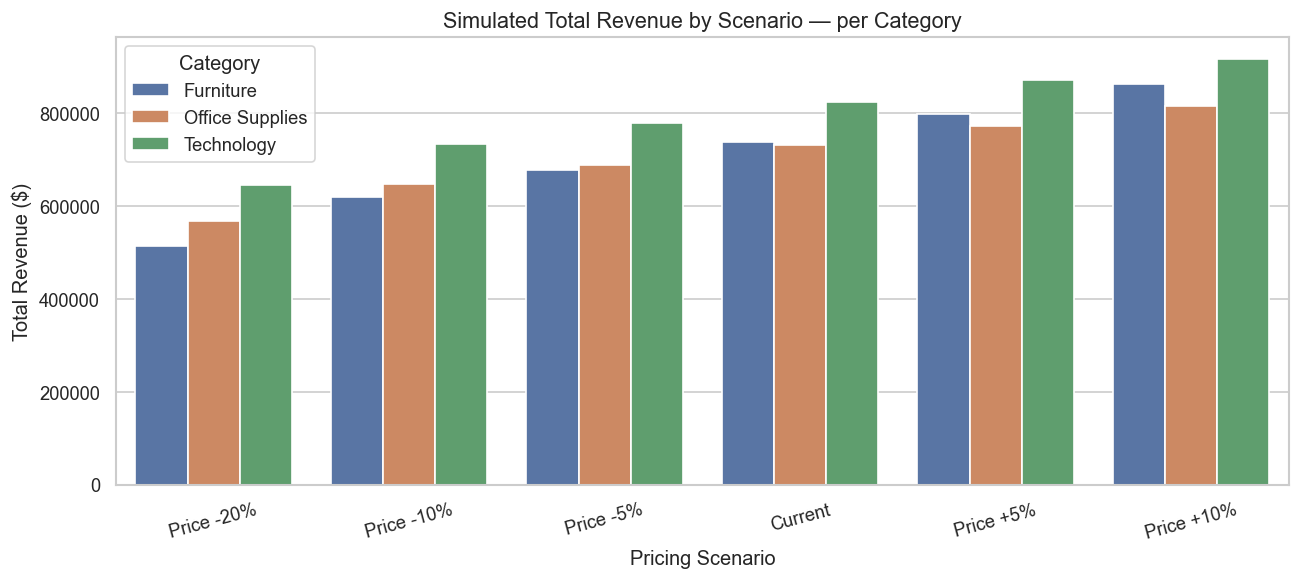

In [8]:
plt.figure(figsize=(11, 5))
sns.barplot(data=cat_sim, x='Scenario', y='Total_Revenue', hue='Category')
plt.title("Simulated Total Revenue by Scenario — per Category", fontsize=13)
plt.xlabel("Pricing Scenario")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../outputs/12_revenue_by_scenario.png')
plt.show()

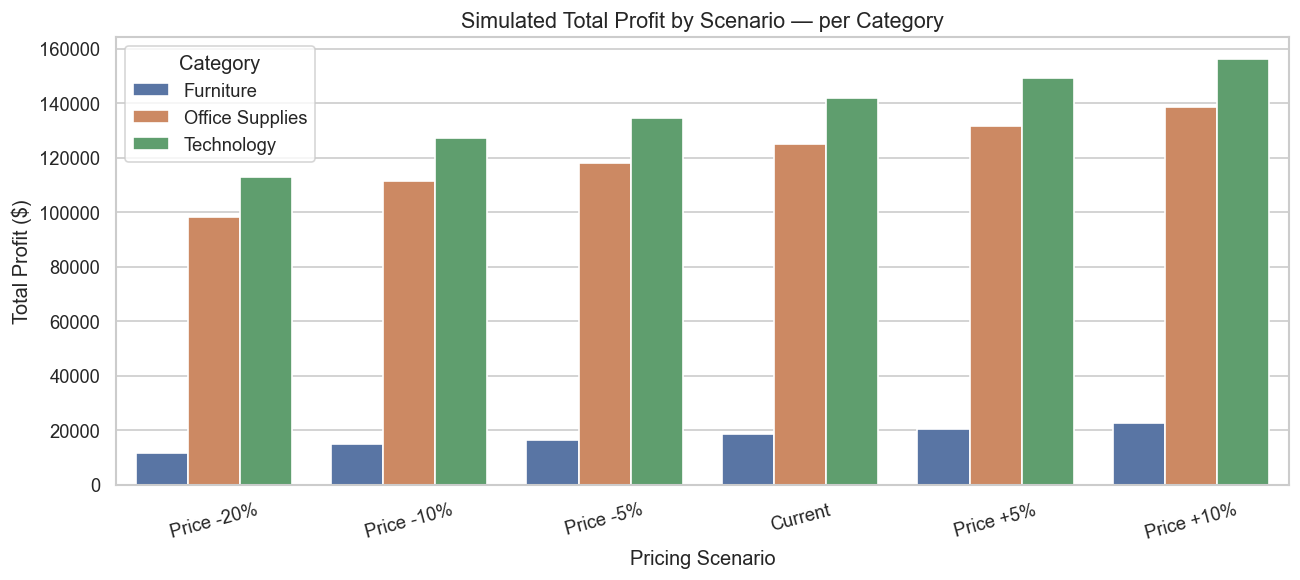

In [9]:
plt.figure(figsize=(11, 5))
sns.barplot(data=cat_sim, x='Scenario', y='Total_Profit', hue='Category')
plt.title("Simulated Total Profit by Scenario — per Category", fontsize=13)
plt.xlabel("Pricing Scenario")
plt.ylabel("Total Profit ($)")
plt.xticks(rotation=15)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('../outputs/13_profit_by_scenario.png')
plt.show()

In [10]:
best_scenario = sim_df.loc[
    sim_df.groupby('Sub-Category')['New_Profit'].idxmax()
][['Sub-Category', 'Category', 'Scenario', 'New_Revenue', 'New_Profit',
   'Revenue_Change', 'Profit_Change', 'Demand_Response']].reset_index(drop=True)

print("=== Best Pricing Scenario per Sub-Category ===")
print(best_scenario.to_string(index=False))

=== Best Pricing Scenario per Sub-Category ===
Sub-Category        Category   Scenario  New_Revenue  New_Profit  Revenue_Change  Profit_Change          Demand_Response
 Accessories      Technology Price +10%    183165.62    45891.60        15785.30        3954.96    Unusual — Investigate
  Appliances Office Supplies Price +10%    116353.88    19626.01         8821.72        1488.00    Unusual — Investigate
         Art Office Supplies Price +10%     29949.87     7208.88         2842.84         684.27    Unusual — Investigate
     Binders Office Supplies Price +10%    240181.49    35692.62        36772.32        5464.62 Inelastic — Price Stable
   Bookcases       Furniture Price -20%     69405.72    -2097.98       -45474.28        1374.58    Unusual — Investigate
      Chairs       Furniture Price +10%    380586.93    30847.43        52809.17        4280.30    Unusual — Investigate
     Copiers      Technology Price +10%    158848.58    59084.65         9320.55        3466.83    Unusual

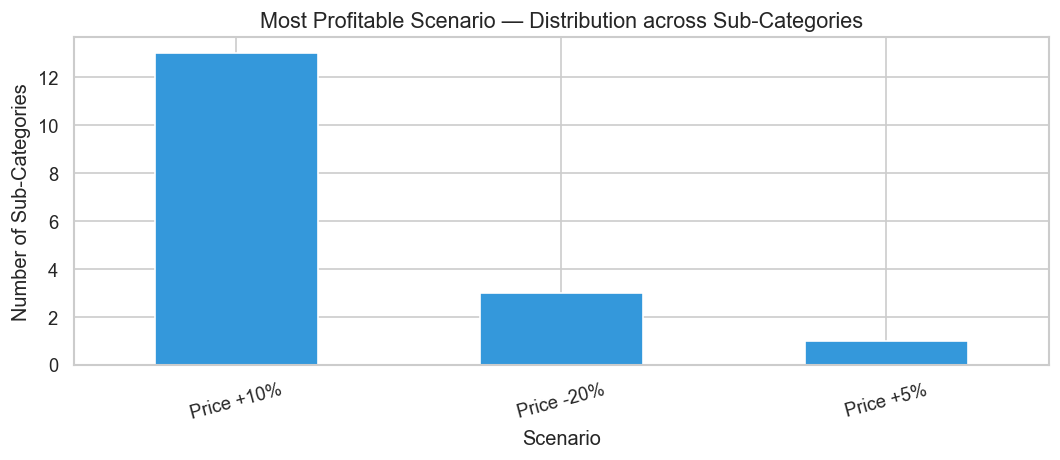

In [11]:
plt.figure(figsize=(9, 4))
best_scenario['Scenario'].value_counts().plot(kind='bar', color='#3498db')
plt.title("Most Profitable Scenario — Distribution across Sub-Categories", fontsize=13)
plt.xlabel("Scenario")
plt.ylabel("Number of Sub-Categories")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../outputs/14_best_scenario_distribution.png')
plt.show()

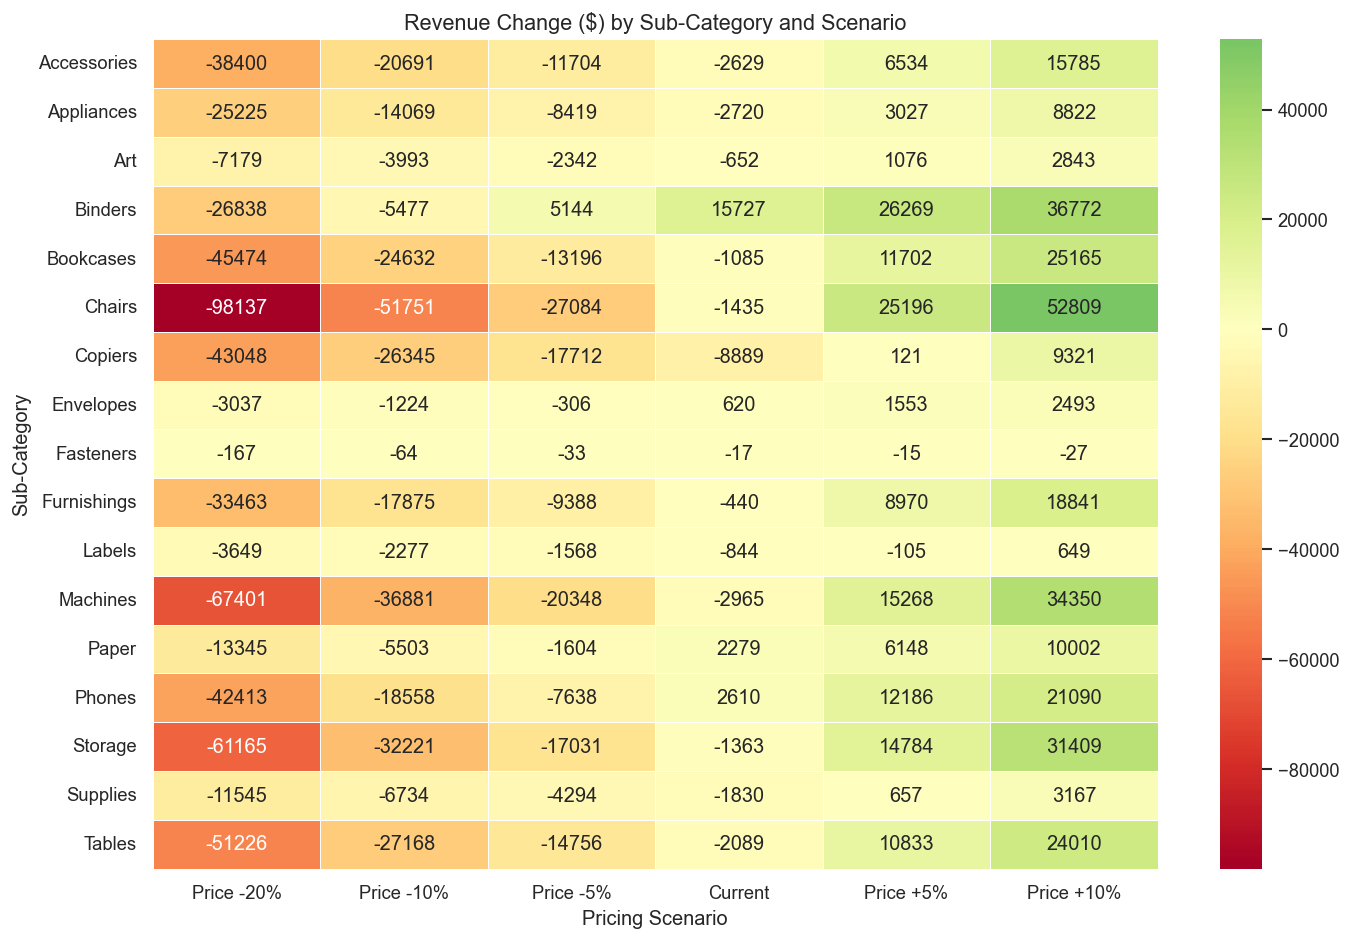

In [12]:
revenue_pivot = sim_df.groupby(
    ['Sub-Category', 'Scenario'])['Revenue_Change'].sum().unstack()
revenue_pivot = revenue_pivot[scenario_order]

plt.figure(figsize=(12, 8))
sns.heatmap(
    revenue_pivot,
    annot=True, fmt='.0f',
    cmap='RdYlGn', linewidths=0.5, center=0
)
plt.title("Revenue Change ($) by Sub-Category and Scenario", fontsize=13)
plt.xlabel("Pricing Scenario")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.savefig('../outputs/15_revenue_change_heatmap.png')
plt.show()

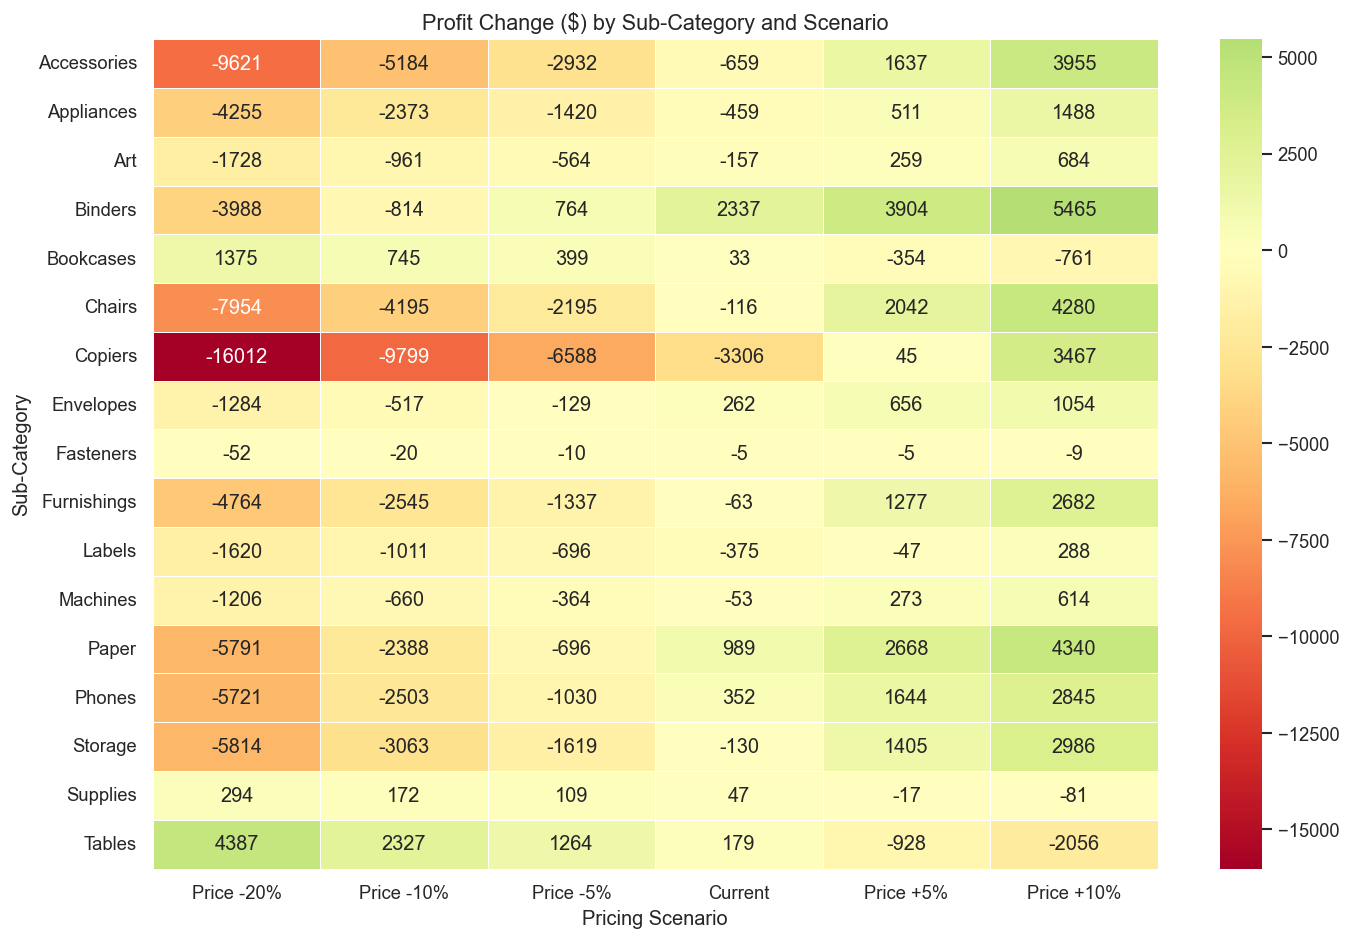

In [13]:
profit_pivot = sim_df.groupby(
    ['Sub-Category', 'Scenario'])['Profit_Change'].sum().unstack()
profit_pivot = profit_pivot[scenario_order]

plt.figure(figsize=(12, 8))
sns.heatmap(
    profit_pivot,
    annot=True, fmt='.0f',
    cmap='RdYlGn', linewidths=0.5, center=0
)
plt.title("Profit Change ($) by Sub-Category and Scenario", fontsize=13)
plt.xlabel("Pricing Scenario")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.savefig('../outputs/16_profit_change_heatmap.png')
plt.show()

In [14]:
sim_df.to_csv('../outputs/pricing_summary.csv', index=False)
best_scenario.to_csv('../outputs/best_scenario_per_subcategory.csv', index=False)

print("Simulation results saved")
print("Best scenario table saved")

Simulation results saved
Best scenario table saved


In [15]:
print("SCENARIO SIMULATION — SUMMARY")

print("\nBest Scenario Distribution:")
print(best_scenario['Scenario'].value_counts())

print("\nCategory Level — Best Profit Scenario:")
best_cat = cat_sim.loc[cat_sim.groupby('Category')['Total_Profit'].idxmax()]
print(best_cat[['Category', 'Scenario', 'Total_Profit',
                 'Total_Revenue']].to_string(index=False))

print("\nTop 5 Sub-Categories by Profit Improvement:")
print(best_scenario.nlargest(5, 'Profit_Change')
      [['Sub-Category', 'Scenario', 'Profit_Change']].to_string(index=False))

print("\nBottom 5 Sub-Categories (Biggest Loss Risk):")
print(best_scenario.nsmallest(5, 'New_Profit')
      [['Sub-Category', 'Scenario', 'New_Profit']].to_string(index=False))

print("\nSimulation Note:")
print("Results are directional estimates based on proxy elasticity.")
print("Present as scenario comparisons, not exact financial forecasts.")

SCENARIO SIMULATION — SUMMARY

Best Scenario Distribution:
Scenario
Price +10%    13
Price -20%     3
Price +5%      1
Name: count, dtype: int64

Category Level — Best Profit Scenario:
       Category   Scenario  Total_Profit  Total_Revenue
      Furniture Price +10%      22567.45      862132.07
Office Supplies Price +10%     138580.36      814865.57
     Technology Price +10%     156335.99      916699.36

Top 5 Sub-Categories by Profit Improvement:
Sub-Category   Scenario  Profit_Change
     Binders Price +10%        5464.62
      Tables Price -20%        4387.27
       Paper Price +10%        4340.30
      Chairs Price +10%        4280.30
 Accessories Price +10%        3954.96

Bottom 5 Sub-Categories (Biggest Loss Risk):
Sub-Category   Scenario  New_Profit
      Tables Price -20%   -13338.21
   Bookcases Price -20%    -2097.98
    Supplies Price -20%     -894.97
   Fasteners  Price +5%      944.78
    Machines Price +10%     3999.15

Simulation Note:
Results are directional estimate

In [ ]:
Scenario Simulation — Conclusions

Methodology Note
This simulation uses proxy elasticity values from Step 3 as demand response estimates.
Results are directional — they show which pricing direction is likely most beneficial.
Profit margin is assumed proportional to base margin (simplification).
Do not interpret outputs as exact financial forecasts.

What the Simulation Answers
1. Should we discount? → Only where demand response justifies the margin loss
2. Should we increase price? → Yes, for moderate/stable demand sub-categories
3. Where is current pricing already optimal? → Where Current = best scenario
4. Where is correction most urgent? → Loss-making sub-categories from EDA

Key Outputs
- Best scenario identified per sub-category
- Revenue and profit heatmaps show impact direction clearly
- Category level simulation shows overall pricing direction

Final Note
Based on observed demand response patterns and scenario simulation,
pricing recommendations are made directionally — not as exact price points.
This is transparent, defensible, and appropriate given the dataset limitations.